In [ ]:
#Carregar arquivos e mostrar o resultado
import pandas as pd
df = pd.read_csv("sample_data/mlflow_test_smells.csv")
df.head()

,test_name,file,test_size,assert_count,undocumented_asserts,call_count,variable_count,fixture_count,external_resource_count,constructor_count,mock_count,asserted_variables_count,cyclomatic_complexity,assertion_roulette,eager_test,mystery_guest,general_fixture,flaky_test,unknown_test
0,test_mlflow_server_command,test_cli.py,17,1,1,8,2,1,0,2,0,1,3,0,0,0,0,0,0
1,test_server_static_prefix_validation,test_cli.py,15,2,2,16,2,0,0,4,4,1,5,0,0,0,0,0,0
2,test_server_cli_fails_when_workspace_env_set,test_cli.py,14,2,2,2,4,0,0,0,0,1,1,0,0,0,0,0,0
3,test_server_uvicorn_options,test_cli.py,50,0,0,8,0,0,0,2,2,0,3,0,0,0,0,0,1
4,test_server_dev_mode,test_cli.py,25,0,0,6,0,0,0,1,1,0,2,0,0,0,0,0,1


In [ ]:
df[df["assertion_roulette"] == 1][
    ["test_size", "assert_count", "call_count", "variable_count", "cyclomatic_complexity"]
].describe()

,test_size,assert_count,call_count,variable_count,cyclomatic_complexity
count,4740.000000,4740.000000,4740.000000,4740.000000,4740.000000
mean,29.928692,5.878903,10.786920,5.180591,2.269198
std,22.195471,4.368606,8.983007,4.443436,1.669489
min,4.000000,3.000000,0.000000,0.000000,1.000000
25%,15.000000,3.000000,5.000000,2.000000,1.000000
50%,24.000000,4.000000,9.000000,4.000000,2.000000
75%,38.000000,7.000000,13.250000,7.000000,3.000000
max,249.000000,60.000000,137.000000,65.000000,19.000000


In [ ]:
df[df["assertion_roulette"] == 0][
    ["test_size", "assert_count", "call_count", "variable_count"]
].describe()

,test_size,assert_count,call_count,variable_count
count,7035.000000,7035.000000,7035.000000,7035.000000
mean,14.802132,1.302914,5.914144,2.730206
std,14.418185,0.720303,5.292230,2.635466
min,2.000000,0.000000,0.000000,0.000000
25%,6.000000,1.000000,3.000000,1.000000
50%,11.000000,1.000000,5.000000,2.000000
75%,19.000000,2.000000,7.000000,4.000000
max,272.000000,5.000000,94.000000,40.000000


In [ ]:
df.groupby("assertion_roulette")[
    ["test_size", "assert_count", "call_count", "variable_count"]
].mean().round(2)

,test_size,assert_count,call_count,variable_count
assertion_roulette,,,,
0,14.80,1.30,5.91,2.73
1,29.93,5.88,10.79,5.18


Comparação(considerando a média)  entre testes com Assertion roulette e sem Assertion , usando as metricas que o define:

Com esse resultado, dá para afirmar que
Testes com Assertion Roulette são maiores(29.93 vs 14.90)

Testes com Assertion Roulette tem mais asserts (5.88 vs 1.30)

Testes com Assertion Roulette realizem  mais chamadas de funções (10.79 vs 5.91)

Testes com Assertion Roulette realizem mais atribuições de variáveis.(2.73 vs 5.18)

In [ ]:
# Eager Test
df.groupby("eager_test")[
    ["test_size", "assert_count", "call_count", "variable_count"]
].mean().round(2)

,test_size,assert_count,call_count,variable_count
eager_test,,,,
0,20.74,3.14,7.74,3.66
1,29.41,3.60,15.91,7.21


A partir desses analises, podemos afirmar que:
Testes como Eager Test possui tamanho medio maiores.
A quantidade média de asserções mudou um pouco .
O número medio de chamadas de funções praticamente dobrou.
A quantidade de atribuições de variaveis também aumentou.
Se um teste está chamando quase 16 funções em média, enquanto os demais chamam cerca de 8, isso é uma evidência quantitativa forte de que o teste está acumulando responsabilidades.
isso combina com a definição do smell.


In [ ]:
#mystery guest
df.groupby("mystery_guest")[
    ["external_resource_count","call_count"]
].mean().round(2)

,external_resource_count,call_count
mystery_guest,,
0,0.00,7.71
1,1.39,13.68


Após esse resultado, podemos concluir que:
Testes sem Mystery Guest praticamente não apresentam acessos a recursos externos(0.00)
Testes com Mystery Guest apresenta em media 1,39 de acesso a recursos externos
Testes com Mystery Guest executam quase o dobro de chamadas de função(13.68 vs 7.71)

In [ ]:
df.groupby("flaky_test")[
    ["test_size",
     "call_count",
     "variable_count",
     "external_resource_count"]
].mean().round(2)

,test_size,call_count,variable_count,external_resource_count
flaky_test,,,,
0,20.64,7.76,3.67,0.04
1,38.56,15.91,6.99,0.09


In [ ]:
df["flaky_test"].value_counts()

,count
flaky_test,
0,11613
1,162


O ponto mais forte aqui parece ser o call_count e o test_size, não external resources. Isso nós levar a perceber algo interessante: Flaky Test identificados no MlFlow(dataset) parecem estar mais associados a complexidade estrutural do teste do que apenas a dependências externas.
Além disso Flaky Test é relativamente raro no dataset pois em aproximademente 11613 testes só tivemos 162 casos de flaky test, mais ou menos 1,38 %

In [ ]:
import pandas as pd
df = pd.read_csv("sample_data/scikit-learn_test_smells_report.csv")
df.head()

,test_name,file,test_size,assert_count,undocumented_asserts,call_count,variable_count,fixture_count,external_resource_count,constructor_count,mock_count,asserted_variables_count,cyclomatic_complexity,assertion_roulette,eager_test,mystery_guest,general_fixture,flaky_test,unknown_test
0,test_clone,test_base.py,16,3,3,7,4,0,0,0,0,2,1,1,0,0,0,0,0
1,test_clone_2,test_base.py,12,1,1,3,3,0,0,0,0,2,1,0,0,0,0,0,0
2,test_clone_buggy,test_base.py,18,8,8,12,5,0,0,4,0,0,5,1,0,0,0,0,0
3,test_clone_empty_array,test_base.py,13,3,3,14,6,0,0,0,0,0,1,1,0,0,0,0,0
4,test_clone_nan,test_base.py,6,1,1,2,2,0,0,0,0,2,1,0,0,0,0,0,0


In [ ]:
#fazendo uma comparação com os 2 datasets
import pandas as pd

mlflow = pd.read_csv("sample_data/mlflow_test_smells.csv")
sklearn = pd.read_csv("sample_data/scikit-learn_test_smells_report.csv")

mlflow["dataset"] = "MLflow"
sklearn["dataset"] = "Scikit-learn"

df = pd.concat([mlflow, sklearn], ignore_index=True)

df.head()

,test_name,file,test_size,assert_count,undocumented_asserts,call_count,variable_count,fixture_count,external_resource_count,constructor_count,mock_count,asserted_variables_count,cyclomatic_complexity,assertion_roulette,eager_test,mystery_guest,general_fixture,flaky_test,unknown_test,dataset
0,test_mlflow_server_command,test_cli.py,17,1,1,8,2,1,0,2,0,1,3,0,0,0,0,0,0,MLflow
1,test_server_static_prefix_validation,test_cli.py,15,2,2,16,2,0,0,4,4,1,5,0,0,0,0,0,0,MLflow
2,test_server_cli_fails_when_workspace_env_set,test_cli.py,14,2,2,2,4,0,0,0,0,1,1,0,0,0,0,0,0,MLflow
3,test_server_uvicorn_options,test_cli.py,50,0,0,8,0,0,0,2,2,0,3,0,0,0,0,0,1,MLflow
4,test_server_dev_mode,test_cli.py,25,0,0,6,0,0,0,1,1,0,2,0,0,0,0,0,1,MLflow


In [ ]:
# Total de funções de teste analisadas por projeto
df.groupby("dataset")["test_name"].count()

,test_name
dataset,
MLflow,11775
Scikit-learn,510


1) Quantidade de ocorrências de cada test smell por projeto

In [ ]:
smells = [
    "assertion_roulette",
    "eager_test",
    "mystery_guest",
    "general_fixture",
    "flaky_test"
]

df.groupby("dataset")[smells].sum()

,assertion_roulette,eager_test,mystery_guest,general_fixture,flaky_test
dataset,,,,,
MLflow,4740,199,323,23,162
Scikit-learn,177,43,20,0,14


2) Quantidade de funções de teste analisadas

In [ ]:
df.groupby("dataset")["test_name"].count()

,test_name
dataset,
MLflow,11775
Scikit-learn,510


3) Quantidade de arquivos analisados

In [ ]:
df.groupby("dataset")["file"].nunique()

,file
dataset,
MLflow,626
Scikit-learn,24


4) Em quantos arquivos apareceu cada smell

In [ ]:
for smell in smells:
    print(f"\n===== {smell} =====")
    print(
        df[df[smell] == 1]
        .groupby("dataset")["file"]
        .nunique()
    )


===== assertion_roulette =====
dataset
MLflow          509
Scikit-learn     15
Name: file, dtype: int64

===== eager_test =====
dataset
MLflow          74
Scikit-learn    10
Name: file, dtype: int64

===== mystery_guest =====
dataset
MLflow          86
Scikit-learn     5
Name: file, dtype: int64

===== general_fixture =====
dataset
MLflow    8
Name: file, dtype: int64

===== flaky_test =====
dataset
MLflow          65
Scikit-learn     9
Name: file, dtype: int64


5) Quais arquivos possuem cada smell

In [ ]:
for smell in smells:
    print(f"\n===== {smell} =====")

    display(
        df[df[smell] == 1][["dataset", "file"]]
        .drop_duplicates()
        .sort_values(["dataset","file"])
    )


===== assertion_roulette =====


,dataset,file
7534,MLflow,test_abstract_store.py
142,MLflow,test_ag2_autolog.py
2184,MLflow,test_agent_server.py
2242,MLflow,test_agent_tester.py
4083,MLflow,test_agent_trace.py
...,...,...
12053,Scikit-learn,test_multiclass.py
12107,Scikit-learn,test_multioutput.py
12137,Scikit-learn,test_naive_bayes.py
12173,Scikit-learn,test_pipeline.py



===== eager_test =====


,dataset,file
4301,MLflow,test_autolog.py
422,MLflow,test_catboost_model_export.py
5202,MLflow,test_chat_agent.py
4310,MLflow,test_chat_agent_langchain.py
4443,MLflow,test_chat_agent_langgraph.py
...,...,...
12060,Scikit-learn,test_multiclass.py
12110,Scikit-learn,test_multioutput.py
12137,Scikit-learn,test_naive_bayes.py
12178,Scikit-learn,test_pipeline.py



===== mystery_guest =====


,dataset,file
661,MLflow,test_artifact_dataset_sources.py
9963,MLflow,test_artifact_utils.py
4683,MLflow,test_artifacts.py
284,MLflow,test_autologging_behaviors_integration.py
384,MLflow,test_autologging_utils.py
...,...,...
11797,Scikit-learn,test_base.py
12049,Scikit-learn,test_min_dependencies_readme.py
12077,Scikit-learn,test_multiclass.py
12148,Scikit-learn,test_naive_bayes.py



===== general_fixture =====


,dataset,file
208,MLflow,test_artifacts.py
54,MLflow,test_cli.py
6679,MLflow,test_genai_evaluate_invocation.py
5618,MLflow,test_pytorch_autolog.py
6735,MLflow,test_scorer_invocation.py
9332,MLflow,test_tensorflow2_autolog.py
10924,MLflow,test_transformers_peft_model.py
1745,MLflow,test_validation.py



===== flaky_test =====


,dataset,file
7541,MLflow,test_abstract_store.py
145,MLflow,test_ag2_autolog.py
11031,MLflow,test_async_artifacts_logging_queue.py
9702,MLflow,test_async_export_queue.py
4301,MLflow,test_autolog.py
...,...,...
12057,Scikit-learn,test_multiclass.py
12129,Scikit-learn,test_multioutput.py
12139,Scikit-learn,test_naive_bayes.py
12233,Scikit-learn,test_pipeline.py


6) Arquivos com maior quantidade de smells

In [ ]:
df["total_smells"] = df[smells].sum(axis=1)

(
    df.groupby(["dataset","file"])["total_smells"]
      .sum()
      .sort_values(ascending=False)
      .head(20)
)

dataset       file                                        
MLflow        test_fluent.py                                  174
              test_sqlalchemy_store_traces.py                 141
              test_file_store.py                              120
              test_handlers.py                                114
              test_utils.py                                   110
              test_rest_tracking.py                           106
              test_client.py                                  102
              test_cli.py                                      83
              test_sqlalchemy_store.py                         73
              test_evaluation.py                               72
Scikit-learn  test_pipeline.py                                 71
MLflow        test_make_judge.py                               69
              test_default_evaluator.py                        67
              test_transformers_model_export.py                67
              test_langchain_model_export.py                   60
              test_sqlalchemy_workspace_store.py               60
              test_sqlalchemy_store_runs.py                    60
              test_sqlalchemy_store_query_trace_metrics.py     57
              test_assessment.py                               56
              test_builtin_scorers.py                          54
Name: total_smells, dtype: int64

7) Quantidade de funções por arquivo

In [ ]:
(
    df.groupby(["dataset","file"])
      .size()
      .sort_values(ascending=False)
      .head(20)
)

dataset  file                                         
MLflow   test_utils.py                                    324
         test_fluent.py                                   299
         test_client.py                                   233
         test_handlers.py                                 226
         test_cli.py                                      181
         test_sqlalchemy_store_traces.py                  180
         test_file_store.py                               177
         test_auth_workspace.py                           143
         test_rest_tracking.py                            142
         test_builtin_scorers.py                          138
         test_rest_store.py                               130
         test_make_judge.py                               126
         test_transformers_model_export.py                123
         test_gateway_sql_store.py                        119
         test_sqlalchemy_store.py                         113
         test_evaluation.py                               112
         test_default_evaluator.py                        105
         test_model_export_with_class_and_artifacts.py    104
         test_sqlalchemy_store_runs.py                    102
         test_unity_catalog_rest_store.py                  94
dtype: int64

In [ ]:
# Filtra somente testes do MLflow classificados com Assertion Roulette
mlflow_ar = df[
    (df["dataset"] == "MLflow") &
    (df["assertion_roulette"] == 1)
].copy()

# Exibe as medianas das principais métricas
mlflow_ar[
    [
        "test_size",
        "assert_count",
        "call_count",
        "asserted_variables_count",
        "cyclomatic_complexity",
    ]
].median()

,0
test_size,24.0
assert_count,4.0
call_count,9.0
asserted_variables_count,4.0
cyclomatic_complexity,2.0


In [ ]:
sklearn_ar = df[
    (df["dataset"] == "Scikit-learn") &
    (df["assertion_roulette"] == 1)
].copy()

sklearn_ar[
    [
        "test_size",
        "assert_count",
        "call_count",
        "asserted_variables_count",
        "cyclomatic_complexity",
    ]
].median()

,0
test_size,23.0
assert_count,4.0
call_count,14.0
asserted_variables_count,2.0
cyclomatic_complexity,2.0


In [ ]:
metrics = [
    "test_size",
    "assert_count",
    "call_count",
    "asserted_variables_count",
    "cyclomatic_complexity",
]

# Calcula a distância de cada teste para a mediana do grupo
median_mlflow = mlflow_ar[metrics].median()

mlflow_ar["distance_to_median"] = (
    mlflow_ar[metrics] - median_mlflow
).abs().sum(axis=1)

# Mostra os testes mais próximos da mediana
mlflow_ar.sort_values("distance_to_median")[
    ["test_name", "file"] + metrics
].head(10)

,test_name,file,test_size,assert_count,call_count,asserted_variables_count,cyclomatic_complexity
8672,test_upsert_online_scoring_config_overwrites,test_sqlalchemy_store_scorers.py,24,4,9,3,2
11124,test_trace_info_from_proto_handles_uc_schema_l...,test_databricks_tracing_utils.py,24,5,9,4,1
11036,test_end_async_logging,test_async_logging_queue.py,24,4,9,2,2
8132,test_successful_http_request,test_rest_store.py,24,3,9,4,3
4813,test_predict_traces_link_to_active_model,test_python_api.py,25,3,9,4,2
7761,test_delete_trace_tag_fallback,test_databricks_rest_store.py,24,3,8,4,2
3115,test_judge_call_retrieves_relevant_examples,test_optimizer.py,25,3,9,4,2
7228,test_uri_parsing,test_databricks_run_artifact_repo.py,22,4,9,4,2
9128,test_telemetry_collection_stopped_on_error,test_client.py,22,4,9,4,1
3294,test_load_custom_scorers,test_job.py,24,3,9,2,2


In [ ]:
metrics = [
    "test_size",
    "assert_count",
    "call_count",
    "asserted_variables_count",
    "cyclomatic_complexity",
]

sklearn_ar = df[
    (df["dataset"] == "Scikit-learn")
    & (df["assertion_roulette"] == 1)
].copy()

median_sklearn = sklearn_ar[metrics].median()

sklearn_ar["distance_to_median"] = (
    sklearn_ar[metrics] - median_sklearn
).abs().sum(axis=1)

sklearn_ar.sort_values("distance_to_median")[
    ["test_name", "file"] + metrics
].head(10)

,test_name,file,test_size,assert_count,call_count,asserted_variables_count,cyclomatic_complexity
12089,test_ecoc_delegate_sparse_base_estimator,test_multiclass.py,24,5,14,2,3
12219,test_feature_union_duplicate_column_names,test_pipeline.py,24,4,15,3,2
12238,test_feature_union_check_if_fitted,test_pipeline.py,23,4,14,0,3
11962,test_polynomial_count_sketch,test_kernel_approximation.py,24,3,13,2,1
12261,test_pipeline_with_callbacks,test_pipeline.py,23,4,11,2,1
12080,test_ovo_ties,test_multiclass.py,22,3,12,2,1
11976,test_nystroem_approximation,test_kernel_approximation.py,25,4,17,2,2
11849,test_lda_priors,test_discriminant_analysis.py,23,3,12,0,3
12066,test_ovr_multilabel_dataset,test_multiclass.py,24,3,10,1,2
12005,test_invalid_metadata,test_metadata_routing.py,20,4,15,0,3


In [ ]:
metrics = [
    "test_size",
    "call_count",
    "variable_count",
    "cyclomatic_complexity",
]

mlflow_et = df[
    (df["dataset"]=="MLflow") &
    (df["eager_test"]==1)
].copy()

median = mlflow_et[metrics].median()

mlflow_et["distance"] = (
    mlflow_et[metrics]-median
).abs().sum(axis=1)

mlflow_et.sort_values("distance")[
    ["test_name","file"]+metrics
].head(10)

,test_name,file,test_size,call_count,variable_count,cyclomatic_complexity
4398,test_save_load_langchain_binding,test_langchain_model_export.py,25,13,7,2
4408,test_pyfunc_should_not_convert_chat_request_if...,test_langchain_model_export.py,25,12,6,2
5399,test_python_model_local_testing_data_validation,test_pyfunc_model_with_type_hints.py,25,13,4,2
4366,test_langchain_native_log_and_load_model,test_langchain_model_export.py,27,14,6,2
4448,test_langgraph_chat_agent_trace,test_langgraph_autolog.py,28,13,6,2
5363,test_model_log_load_no_active_run,test_model_export_with_loader_module_and_data_...,25,15,5,2
4894,test_model_log_evaluate_pyfunc_format,test_onnx_model_export.py,25,15,5,2
4451,test_langgraph_model_invoke_with_dictionary_pa...,test_langgraph_model_export.py,24,15,6,2
7015,test_model_with_vector_input,test_pyspark_ml_autologging.py,25,15,7,2
5257,test_pyfunc_model_log_load_no_active_run,test_model_export_with_class_and_artifacts.py,23,14,5,2


In [ ]:
metrics = [
    "test_size",
    "call_count",
    "variable_count",
    "cyclomatic_complexity",
]

# Apenas testes do Scikit-learn classificados como Eager Test
sklearn_et = df[
    (df["dataset"] == "Scikit-learn") &
    (df["eager_test"] == 1)
].copy()

# Mediana das métricas
median = sklearn_et[metrics].median()

# Distância até a mediana
sklearn_et["distance_to_median"] = (
    sklearn_et[metrics] - median
).abs().sum(axis=1)

# Testes mais representativos
sklearn_et.sort_values("distance_to_median")[
    [
        "test_name",
        "file",
        "test_size",
        "call_count",
        "variable_count",
        "cyclomatic_complexity",
    ]
].head(10)

,test_name,file,test_size,call_count,variable_count,cyclomatic_complexity
12067,test_ovr_multilabel_predict_proba,test_multiclass.py,34,17,10,2
12208,test_feature_union_weights,test_pipeline.py,31,20,10,1
12152,test_discretenb_predict_proba,test_naive_bayes.py,31,23,6,3
11861,test_qda,test_discriminant_analysis.py,25,18,6,2
11976,test_nystroem_approximation,test_kernel_approximation.py,25,17,11,2
12110,test_multi_output_classification,test_multioutput.py,27,19,5,3
11964,test_additive_chi2_sampler,test_kernel_approximation.py,34,20,13,2
12186,test_pipeline_methods_preprocessing_classifier,test_pipeline.py,28,12,12,2
12260,test_feature_union_metadata_routing,test_pipeline.py,39,18,6,3
11796,test_clone_protocol,test_base.py,42,17,7,1


In [ ]:
metrics = [
    "test_size",
    "call_count",
    "variable_count",
    "cyclomatic_complexity",
]

mlflow_mg = df[
    (df["dataset"]=="MLflow") &
    (df["mystery_guest"]==1)
].copy()

median = mlflow_mg[metrics].median()

mlflow_mg["distance"] = (
    mlflow_mg[metrics]-median
).abs().sum(axis=1)

mlflow_mg.sort_values("distance")[
    [
        "test_name",
        "file",
        "test_size",
        "call_count",
        "variable_count",
        "cyclomatic_complexity",
    ]
].head(10)

,test_name,file,test_size,call_count,variable_count,cyclomatic_complexity
4725,test_requirements_path_replacement,test_container.py,22,10,5,3
5360,test_model_save_load,test_model_export_with_loader_module_and_data_...,22,11,4,2
9355,test_keras_autolog_logs_model_signature_by_def...,test_tensorflow2_autolog.py,21,11,6,2
1691,test_pandas_df_regressor_evaluation_mlflow_dat...,test_evaluation.py,22,10,7,3
5674,test_load_model_raises_exception_when_pickle_m...,test_pytorch_model_export.py,21,11,3,3
5660,test_model_log_persists_specified_conda_env_in...,test_pytorch_model_export.py,22,11,7,4
11266,test_safe_extractall_blocks_symlink_escape,test_file_utils.py,24,11,6,4
1105,test_save_model_custom_signature,test_diffusers_model_export.py,21,11,3,2
6939,test_sparkml_model_log_persists_specified_cond...,test_spark_model_export.py,22,10,7,4
6768,test_log_explanation_doesnt_create_autologged_run,test_log.py,22,10,8,3


In [ ]:
metrics = [
    "test_size",
    "call_count",
    "variable_count",
    "cyclomatic_complexity",
]

# Apenas testes do Scikit-learn classificados como Mystery Guest
sklearn_mg = df[
    (df["dataset"] == "Scikit-learn") &
    (df["mystery_guest"] == 1)
].copy()

# Mediana das métricas
median = sklearn_mg[metrics].median()

# Distância até a mediana
sklearn_mg["distance_to_median"] = (
    sklearn_mg[metrics] - median
).abs().sum(axis=1)

# Testes mais representativos
sklearn_mg.sort_values("distance_to_median")[
    [
        "test_name",
        "file",
        "test_size",
        "call_count",
        "variable_count",
        "cyclomatic_complexity",
    ]
].head(10)

,test_name,file,test_size,call_count,variable_count,cyclomatic_complexity
11798,test_pickle_version_warning_is_issued_upon_dif...,test_base.py,17,8,5,2
12155,test_discretenb_provide_prior_with_partial_fit,test_naive_bayes.py,18,9,4,2
11797,test_pickle_version_warning_is_not_raised_with...,test_base.py,14,9,6,2
11799,test_pickle_version_warning_is_issued_when_no_...,test_base.py,15,7,4,2
12097,test_multiclass_estimator_attribute_error,test_multiclass.py,20,7,4,2
12240,test_pipeline_set_output_integration,test_pipeline.py,14,9,4,1
12241,test_feature_union_set_output,test_pipeline.py,15,14,5,2
11800,test_pickle_version_no_warning_is_issued_with_...,test_base.py,14,7,6,3
12050,test_min_dependencies_pyproject_toml,test_min_dependencies_readme.py,15,6,3,3
12224,test_features_names_passthrough,test_pipeline.py,14,7,2,1


In [ ]:
metrics = [
    "fixture_count",
    "variable_count",
    "cyclomatic_complexity",
]

mlflow_gf = df[
    (df["dataset"] == "MLflow") &
    (df["general_fixture"] == 1)
].copy()

median_gf = mlflow_gf[metrics].median()

mlflow_gf["distance_to_median"] = (
    mlflow_gf[metrics] - median_gf
).abs().sum(axis=1)

mlflow_gf.sort_values("distance_to_median")[
    [
        "test_name",
        "file",
        "fixture_count",
        "variable_count",
        "cyclomatic_complexity",
    ]
].head(10)

,test_name,file,fixture_count,variable_count,cyclomatic_complexity
57,test_mlflow_gc_jobs_deleted_with_older_than_flag,test_cli.py,1,5,2
54,test_mlflow_gc_no_jobs_deleted_without_jobs_flag,test_cli.py,1,5,1
56,test_mlflow_gc_specific_jobs_deleted_with_job_ids,test_cli.py,1,5,3
58,test_mlflow_gc_job_ids_with_older_than_filter,test_cli.py,1,6,1
208,test_download_artifacts_with_run_id_no_path,test_artifacts.py,1,4,1
5627,test_pytorch_early_stop_artifacts_logged,test_pytorch_autolog.py,1,4,1
5628,test_pytorch_autolog_model_can_load_from_artifact,test_pytorch_autolog.py,1,4,1
1745,test_validation_value_threshold_should_pass,test_validation.py,3,5,2
5620,test_pytorch_autolog_logs_expected_data,test_pytorch_autolog.py,1,7,2
6735,test_invoke_scorer_missing_trace,test_scorer_invocation.py,2,5,1


In [ ]:
metrics = [
    "test_size",
    "call_count",
    "variable_count",
    "cyclomatic_complexity",
]

mlflow_flaky = df[
    (df["dataset"] == "MLflow") &
    (df["flaky_test"] == 1)
].copy()

median_mlflow = mlflow_flaky[metrics].median()

mlflow_flaky["distance_to_median"] = (
    mlflow_flaky[metrics] - median_mlflow
).abs().sum(axis=1)

mlflow_flaky.sort_values("distance_to_median")[
    ["test_name", "file"] + metrics
].head(10)

,test_name,file,test_size,call_count,variable_count,cyclomatic_complexity
8332,test_search_experiments_filter_by_tag_is_null,test_sqlalchemy_store_experiments.py,29,11,5,3
7843,test_search_experiments_filter_by_tag_is_null,test_file_store.py,29,11,5,3
7842,test_search_experiments_filter_by_tag,test_file_store.py,30,13,9,2
10188,test_latest_models,test_model_registry.py,32,11,5,3
10335,test_search_issues_sorted_by_timestamp,test_rest_tracking.py,29,11,6,3
6672,test_job_cancel,test_endpoint.py,29,10,4,3
9132,test_concurrent_record_addition,test_client.py,32,14,4,4
305,test_client_asynchronous_flush_operates_correctly,test_autologging_client.py,27,11,6,3
10174,test_rest_get_artifact_api_log_image,test_mlflow_artifacts.py,33,14,6,4
10183,test_search_model_versions_max_results,test_model_registry.py,31,14,7,5


In [ ]:
metrics = [
    "test_size",
    "call_count",
    "variable_count",
    "cyclomatic_complexity",
]

sk_flaky = df[
    (df["dataset"] == "Scikit-learn") &
    (df["flaky_test"] == 1)
].copy()

median_sk = sk_flaky[metrics].median()

sk_flaky["distance_to_median"] = (
    sk_flaky[metrics] - median_sk
).abs().sum(axis=1)

sk_flaky.sort_values("distance_to_median")[
    ["test_name", "file"] + metrics
].head(10)

,test_name,file,test_size,call_count,variable_count,cyclomatic_complexity
11794,test_score_sample_weight,test_base.py,13,12,7,1
11856,test_lda_shrinkage,test_discriminant_analysis.py,16,12,5,1
11938,test_isotonic_sample_weight_parameter_default_...,test_isotonic.py,14,10,8,1
12094,test_support_missing_values,test_multiclass.py,12,11,6,1
12129,test_support_missing_values,test_multioutput.py,11,12,5,1
11922,test_permutation_invariance,test_isotonic.py,12,6,7,1
12233,test_pipeline_missing_values_leniency,test_pipeline.py,8,9,4,1
11852,test_lda_explained_variance_ratio,test_discriminant_analysis.py,27,12,5,1
11857,test_lda_ledoitwolf,test_discriminant_analysis.py,28,13,10,1
11863,test_qda_ledoitwolf,test_discriminant_analysis.py,28,13,10,1


In [ ]:
#comparação direto dos 2 datasets no caso do test smell Assertion Roulette.
df.groupby(["dataset","assertion_roulette"])[
    ["test_size","assert_count","call_count","variable_count", "asserted_variables_count", "cyclomatic_complexity"]
].mean().round(2)

test_size  assert_count  call_count  \
dataset      assertion_roulette                                        
MLflow       0                       14.80          1.30        5.91   
             1                       29.93          5.88       10.79   
Scikit-learn 0                       14.66          1.25        7.89   
             1                       28.29          5.73       16.37   

                                 variable_count  asserted_variables_count  \
dataset      assertion_roulette                                             
MLflow       0                             2.73                      1.46   
             1                             5.18                      4.13   
Scikit-learn 0                             3.87                      0.83   
             1                             6.40                      2.72   

                                 cyclomatic_complexity  
dataset      assertion_roulette                         
MLflow       0                                    1.75  
             1                                    2.27  
Scikit-learn 0                                    1.78  
             1                                    2.50

In [ ]:
# Caracterização estrutural dos testes com e sem Assertion Roulette

assertion_table = (
    df.groupby(["dataset", "assertion_roulette"])[
        [
            "test_size",
            "assert_count",
            "call_count",
            "asserted_variables_count",
            "cyclomatic_complexity",
        ]
    ]
    .mean()
    .round(2)
)

assertion_table

test_size  assert_count  call_count  \
dataset      assertion_roulette                                        
MLflow       0                       14.80          1.30        5.91   
             1                       29.93          5.88       10.79   
Scikit-learn 0                       14.66          1.25        7.89   
             1                       28.29          5.73       16.37   

                                 asserted_variables_count  \
dataset      assertion_roulette                             
MLflow       0                                        NaN   
             1                                        NaN   
Scikit-learn 0                                       0.83   
             1                                       2.72   

                                 cyclomatic_complexity  
dataset      assertion_roulette                         
MLflow       0                                     NaN  
             1                                     NaN  
Scikit-learn 0                                    1.78  
             1                                    2.50

In [ ]:
eager_table = (
    df.groupby(["dataset", "eager_test"])[
        [
            "test_size",
            "call_count",
            "variable_count",
            "cyclomatic_complexity",
        ]
    ]
    .mean()
    .round(2)
)

eager_table

test_size  call_count  variable_count  \
dataset      eager_test                                          
MLflow       0               20.74        7.74            3.66   
             1               29.41       15.91            7.21   
Scikit-learn 0               18.11        9.84            4.37   
             1               33.30       21.67            8.84   

                         cyclomatic_complexity  
dataset      eager_test                         
MLflow       0                            1.95  
             1                            2.83  
Scikit-learn 0                            2.01  
             1                            2.23

In [ ]:
mystery_table = (
    df.groupby(["dataset", "mystery_guest"])[
        [
            "external_resource_count",
            "call_count",
            "cyclomatic_complexity",
        ]
    ]
    .mean()
    .round(2)
)

mystery_table

external_resource_count  call_count  \
dataset      mystery_guest                                        
MLflow       0                                 0.00        7.71   
             1                                 1.39       13.68   
Scikit-learn 0                                 0.00       10.70   
             1                                 1.00       14.00   

                            cyclomatic_complexity  
dataset      mystery_guest                         
MLflow       0                               1.93  
             1                               3.17  
Scikit-learn 0                               2.02  
             1                               2.35

In [ ]:
general_fixture_table = (
    df.groupby(["dataset", "general_fixture"])[
        [
            "fixture_count",
            "variable_count",
            "cyclomatic_complexity",
        ]
    ]
    .mean()
    .round(2)
)

general_fixture_table

fixture_count  variable_count  \
dataset      general_fixture                                  
MLflow       0                         1.02            3.71   
             1                         1.70            4.91   
Scikit-learn 0                         0.53            4.75   

                              cyclomatic_complexity  
dataset      general_fixture                         
MLflow       0                                 1.96  
             1                                 1.78  
Scikit-learn 0                                 2.03

In [ ]:
df.groupby(["dataset", "general_fixture"]).size()

dataset       general_fixture
MLflow        0                  11752
              1                     23
Scikit-learn  0                    510
dtype: int64

In [ ]:
flaky_table = (
    df.groupby(["dataset", "flaky_test"])[
        [
            "test_size",
            "call_count",
            "variable_count",
            "cyclomatic_complexity",
            "external_resource_count",
        ]
    ]
    .mean()
    .round(2)
)

flaky_table

test_size  call_count  variable_count  \
dataset      flaky_test                                          
MLflow       0               20.64        7.76            3.67   
             1               38.56       15.91            6.99   
Scikit-learn 0               19.39       10.76            4.68   
             1               19.64       13.57            7.14   

                         cyclomatic_complexity  external_resource_count  
dataset      flaky_test                                                  
MLflow       0                             NaN                     0.04  
             1                             NaN                     0.09  
Scikit-learn 0                            2.05                     0.04  
             1                            1.14                     0.00

Calcular as médias dos testes que possuem o smell

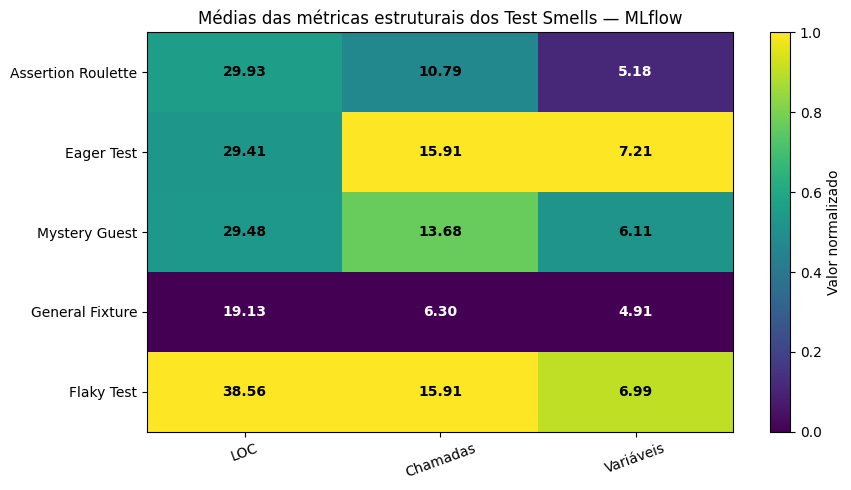

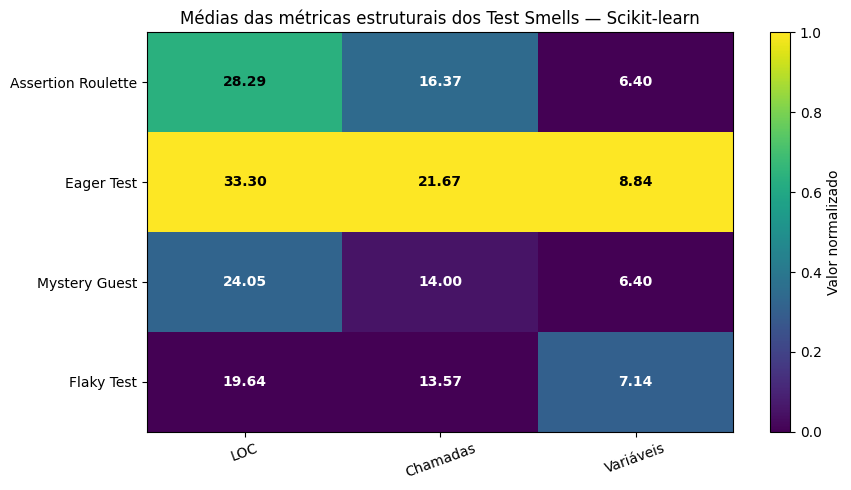

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Smells analisados
smells = {
    "Assertion Roulette": "assertion_roulette",
    "Eager Test": "eager_test",
    "Mystery Guest": "mystery_guest",
    "General Fixture": "general_fixture",
    "Flaky Test": "flaky_test",
}

# Métricas estruturais usadas no heatmap
metrics = [
    "test_size",
    "call_count",
    "variable_count",
]

# Nomes exibidos no gráfico
metric_labels = [
    "LOC",
    "Chamadas",
    "Variáveis",
]


def plot_heatmap_by_dataset(df, dataset_name):
    # Filtra apenas o dataset desejado
    df_dataset = df[df["dataset"] == dataset_name]

    # Calcula a média das métricas apenas para testes com cada smell
    heatmap = pd.DataFrame(columns=metrics)

    for smell_name, smell_col in smells.items():
        values = df_dataset[df_dataset[smell_col] == 1][metrics].mean()
        heatmap.loc[smell_name] = values

    # Remove linhas totalmente vazias, caso algum smell não exista no dataset
    heatmap = heatmap.dropna(how="all")

    # Normaliza cada coluna entre 0 e 1
    heatmap_norm = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min())

    # Evita problemas quando uma coluna tem o mesmo valor em todas as linhas
    heatmap_norm = heatmap_norm.fillna(0)

    # Cria o gráfico
    plt.figure(figsize=(9, 5))
    plt.imshow(heatmap_norm, aspect="auto")

    # Rótulos dos eixos
    plt.xticks(range(len(heatmap.columns)), metric_labels, rotation=20)
    plt.yticks(range(len(heatmap.index)), heatmap.index)

    plt.colorbar(label="Valor normalizado")
    plt.title(f"Médias das métricas estruturais dos Test Smells — {dataset_name}")

    # Escreve os valores reais dentro das células
    for i in range(len(heatmap.index)):
        for j in range(len(heatmap.columns)):
            value = heatmap.iloc[i, j]

            if pd.notna(value):
                # Texto branco em células escuras e preto em células claras
                text_color = "white" if heatmap_norm.iloc[i, j] < 0.35 else "black"

                plt.text(
                    j,
                    i,
                    f"{value:.2f}",
                    ha="center",
                    va="center",
                    fontsize=10,
                    fontweight="bold",
                    color=text_color,
                )

    plt.tight_layout()
    plt.show()

    return heatmap


mlflow_heatmap = plot_heatmap_by_dataset(df, "MLflow")
sklearn_heatmap = plot_heatmap_by_dataset(df, "Scikit-learn")

MlFow

Quantidade de smell por dataset

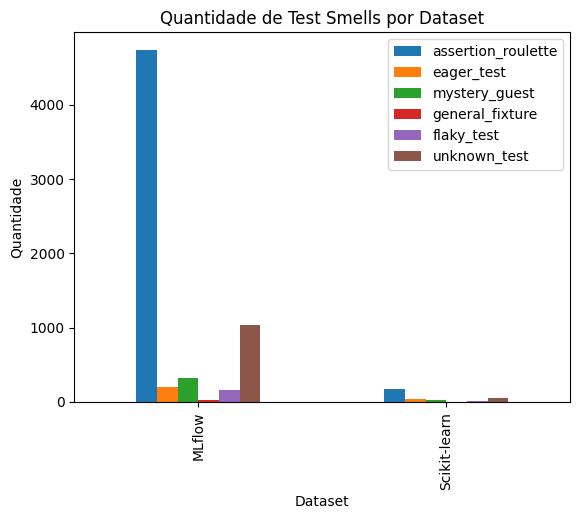

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Carrega os dados dos arquivos CSV e concatena-os
mlflow = pd.read_csv("sample_data/mlflow_test_smells_report.csv")
sklearn = pd.read_csv("sample_data/sklearn_test_smells_report.csv")

mlflow["dataset"] = "MLflow"
sklearn["dataset"] = "Scikit-learn"

df = pd.concat([mlflow, sklearn], ignore_index=True)

# Lista contendo as colunas que representam cada test smell
# Cada coluna possui valores binários:
# 0 -> smell não detectado
# 1 -> smell detectado
smells = [
    "assertion_roulette",
    "eager_test",
    "mystery_guest",
    "general_fixture",
    "flaky_test",
    "unknown_test"
]

# Agrupa os dados pelo dataset (MLflow ou Scikit-learn)
# Em seguida soma as ocorrências de cada smell
# Como os valores são binários (0 e 1),
# a soma corresponde ao número total de ocorrências
df.groupby("dataset")[smells].sum().plot(kind="bar")

# Define o rótulo do eixo X
plt.xlabel("Dataset")

# Define o rótulo do eixo Y
plt.ylabel("Quantidade")

# Define o título do gráfico
plt.title("Quantidade de Test Smells por Dataset")

# Exibe o gráfico
plt.show()

Tamanho médio dos testes com e sem smell

Testes com smells tendem a ser maiores?

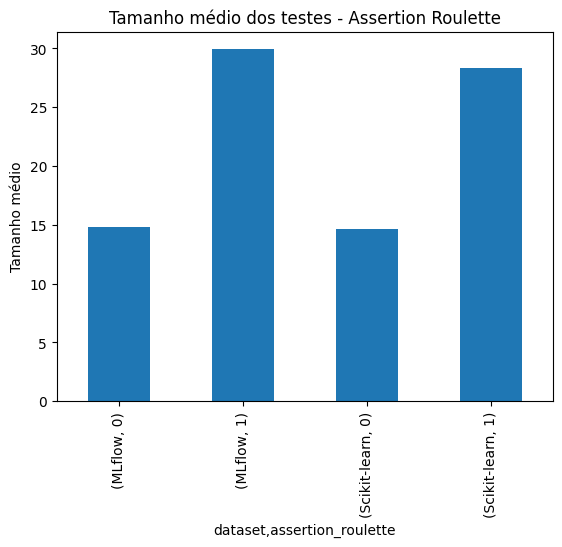

In [ ]:
#Assertion Roulette

df.groupby(["dataset","assertion_roulette"])["test_size"]\
.mean().plot(kind="bar")

plt.ylabel("Tamanho médio")
plt.title("Tamanho médio dos testes - Assertion Roulette")

plt.show()

3. Chamadas de função no Eager Test

Pergunta:

Eager Test realmente executa mais operações?

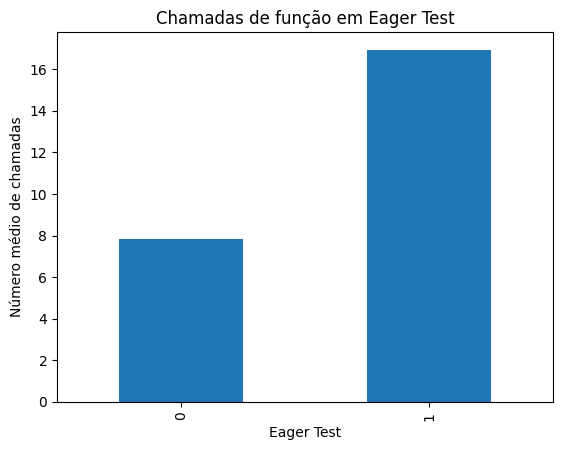

In [ ]:
df.groupby(["eager_test"])["call_count"]\
.mean().plot(kind="bar")
plt.xlabel("Eager Test")
plt.ylabel("Número médio de chamadas")
plt.title("Chamadas de função em Eager Test")

plt.show()

analise com histograma para confirmar a minha analise.

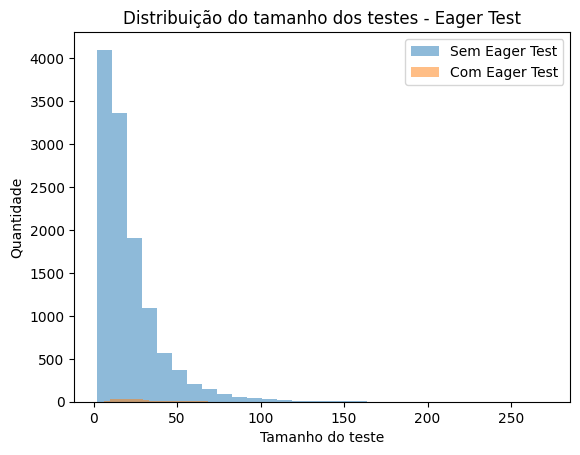

In [ ]:
# Histograma para testes SEM Eager Test
plt.hist(
    df[df["eager_test"] == 0]["test_size"],
    bins=30,
    alpha=0.5,
    label="Sem Eager Test"
)

# Histograma para testes COM Eager Test
plt.hist(
    df[df["eager_test"] == 1]["test_size"],
    bins=30,
    alpha=0.5,
    label="Com Eager Test"
)

plt.xlabel("Tamanho do teste")
plt.ylabel("Quantidade")
plt.title("Distribuição do tamanho dos testes - Eager Test")

plt.legend()
plt.show()

Recursos externos no Mystery Guest

Pergunta:

Mystery Guest realmente acessa mais recursos externos?

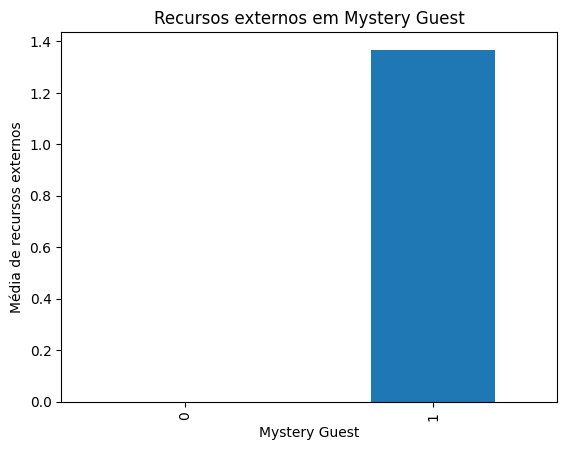

In [ ]:
df.groupby(["mystery_guest"])["external_resource_count"]\
.mean().plot(kind="bar")

plt.xlabel("Mystery Guest")
plt.ylabel("Média de recursos externos")
plt.title("Recursos externos em Mystery Guest")

plt.show()

Histograma do tamanho dos testes

Pergunta:

Como o tamanho dos testes está distribuído?

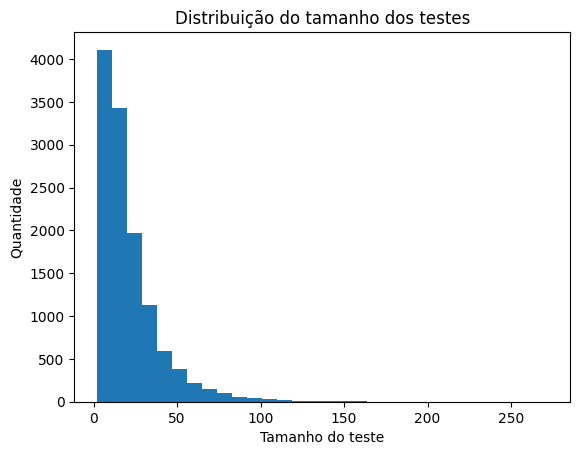

In [ ]:
plt.hist(df["test_size"], bins=30)

plt.xlabel("Tamanho do teste")
plt.ylabel("Quantidade")
plt.title("Distribuição do tamanho dos testes")

plt.show()

Uma análise interessante agora seria sobrepor a distribuição de testes com e sem determinado smell. Exemplo para Assertion Roulette:

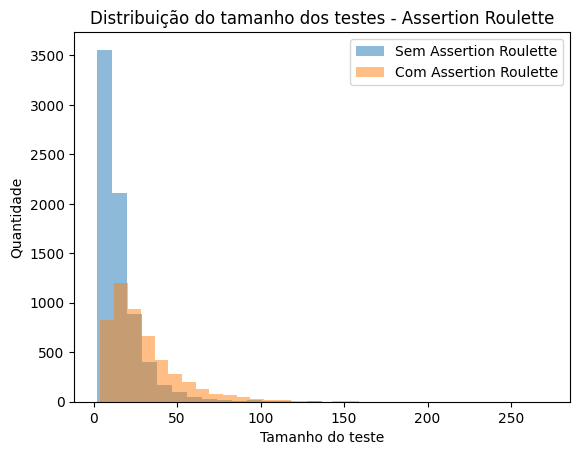

In [ ]:
# Histograma para testes SEM Assertion Roulette
plt.hist(
    df[df["assertion_roulette"] == 0]["test_size"],
    bins=30,
    alpha=0.5,
    label="Sem Assertion Roulette"
)

# Histograma para testes COM Assertion Roulette
plt.hist(
    df[df["assertion_roulette"] == 1]["test_size"],
    bins=30,
    alpha=0.5,
    label="Com Assertion Roulette"
)

plt.xlabel("Tamanho do teste")
plt.ylabel("Quantidade")
plt.title("Distribuição do tamanho dos testes - Assertion Roulette")

plt.legend()
plt.show()

Gráfico de correlação sobre todas metricas.

quais métricas parecem andar juntos?

1. Comparar as novas métricas por dataset(complexidade ciclomatica, construtores logicos, mock)

primeiro carregar os dois  (CSV) e juntar com a colona dataset

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

mlflow = pd.read_csv("sample_data/mlflow_test_smells_report.csv")
sklearn = pd.read_csv("sample_data/scikit-learn_test_smells_report.csv")

mlflow["dataset"] = "MLflow"
sklearn["dataset"] = "Scikit-learn"

df = pd.concat([mlflow, sklearn], ignore_index=True)

df.head()

,test_name,file,test_size,assert_count,undocumented_asserts,call_count,variable_count,fixture_count,external_resource_count,constructor_count,mock_count,asserted_variables_count,cyclomatic_complexity,assertion_roulette,eager_test,mystery_guest,general_fixture,flaky_test,unknown_test,dataset
0,test_mlflow_server_command,test_cli.py,17,1,1,8,2,1,0,2,0,1,3,0,0,0,0,0,0,MLflow
1,test_server_static_prefix_validation,test_cli.py,15,2,2,16,2,0,0,4,4,1,5,0,0,0,0,0,0,MLflow
2,test_server_cli_fails_when_workspace_env_set,test_cli.py,14,2,2,2,4,0,0,0,0,1,1,0,0,0,0,0,0,MLflow
3,test_server_uvicorn_options,test_cli.py,50,0,0,8,0,0,0,2,2,0,3,0,0,0,0,0,1,MLflow
4,test_server_dev_mode,test_cli.py,25,0,0,6,0,0,0,1,1,0,2,0,0,0,0,0,1,MLflow


In [ ]:
df.groupby("dataset")[
    [
        "constructor_count",
        "cyclomatic_complexity",
        "mock_count",
        "asserted_variable_count"
    ]
].mean().round(2)

,constructor_count,cyclomatic_complexity,mock_count,asserted_variables_count
dataset,,,,
MLflow,0.96,1.96,0.43,2.53
Scikit-learn,1.03,2.03,0.00,1.49


testando para o smell Assertion Roulette

In [ ]:
df.groupby(["dataset", "assertion_roulette"])[
    [
        "constructor_count",
        "cyclomatic_complexity",
        "mock_count",
        "asserted_variables_count"
    ]
].mean().round(2)

constructor_count  cyclomatic_complexity  \
dataset      assertion_roulette                                             
MLflow       0                                0.75                   1.75   
             1                                1.27                   2.27   
Scikit-learn 0                                0.78                   1.78   
             1                                1.50                   2.50   

                                 mock_count  asserted_variables_count  
dataset      assertion_roulette                                        
MLflow       0                         0.47                      1.46  
             1                         0.37                      4.13  
Scikit-learn 0                         0.00                      0.83  
             1                         0.00                      2.72

Eager Test

In [ ]:
df.groupby(["dataset", "eager_test"])[
    [
        "constructor_count",
        "cyclomatic_complexity",
        "mock_count",
        "asserted_variables_count"
    ]
].mean().round(2)

constructor_count  cyclomatic_complexity  mock_count  \
dataset      eager_test                                                         
MLflow       0                        0.95                   1.95        0.44   
             1                        1.83                   2.83        0.10   
Scikit-learn 0                        1.01                   2.01        0.00   
             1                        1.23                   2.23        0.00   

                         asserted_variables_count  
dataset      eager_test                            
MLflow       0                               2.50  
             1                               4.21  
Scikit-learn 0                               1.38  
             1                               2.63

Complexidade ciclomática por smells

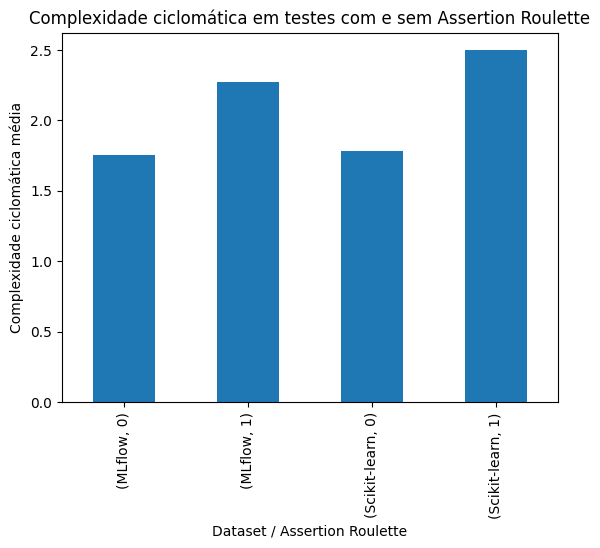

In [ ]:
df.groupby(["dataset", "assertion_roulette"])["cyclomatic_complexity"].mean().plot(kind="bar")

plt.xlabel("Dataset / Assertion Roulette")
plt.ylabel("Complexidade ciclomática média")
plt.title("Complexidade ciclomática em testes com e sem Assertion Roulette")
plt.show()

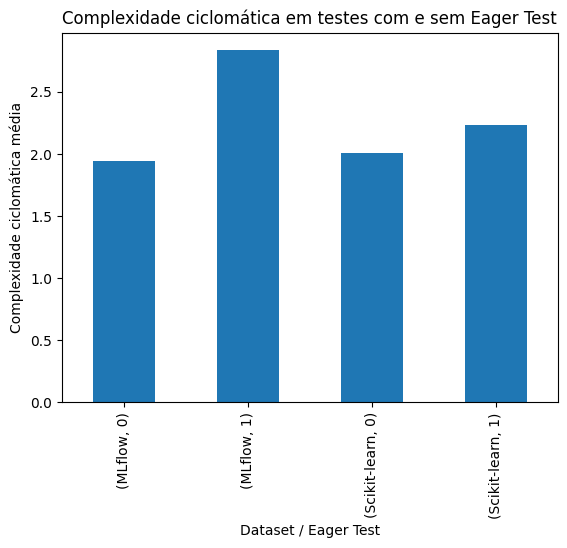

In [ ]:
df.groupby(["dataset", "eager_test"])["cyclomatic_complexity"].mean().plot(kind="bar")

plt.xlabel("Dataset / Eager Test")
plt.ylabel("Complexidade ciclomática média")
plt.title("Complexidade ciclomática em testes com e sem Eager Test")
plt.show()

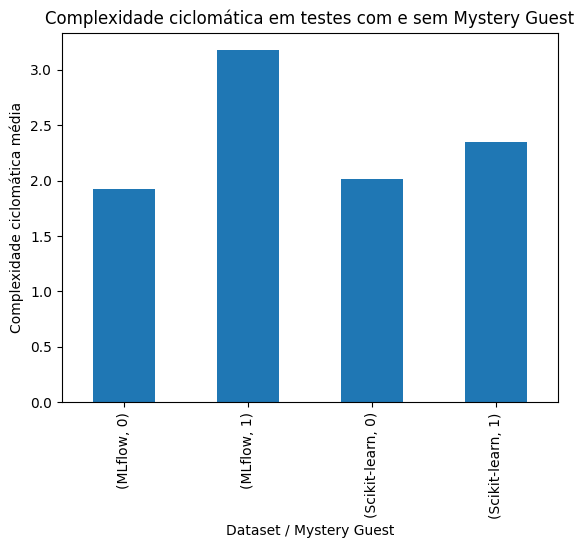

In [ ]:
df.groupby(["dataset", "mystery_guest"])["cyclomatic_complexity"].mean().plot(kind="bar")

plt.xlabel("Dataset / Mystery Guest")
plt.ylabel("Complexidade ciclomática média")
plt.title("Complexidade ciclomática em testes com e sem Mystery Guest")
plt.show()